In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense, BatchNormalization
from sklearn.metrics import classification_report, confusion_matrix

In [26]:
# Load Dataset
X_train_raw = np.loadtxt('DataSet/Train/X_train.txt')
y_train_raw = np.loadtxt('DataSet/Train/y_train.txt').astype(int) - 1  # 将标签转换为 0 索引

X_test = np.loadtxt('DataSet/Test/X_test.txt')
y_test = np.loadtxt('DataSet/Test/y_test.txt').astype(int) - 1



In [27]:
# Encode labels from 1–12 → 0–11
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_raw)
y_test_encoded = le.transform(y_test)

In [28]:
# Balancing the data with SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_raw, y_train_encoded)


In [29]:
# Reshape for CNN input 
X_train_cnn = X_train_balanced.reshape(X_train_balanced.shape[0], X_train_balanced.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


In [30]:
# 3. One-hot encode the labels
y_train_balanced_cat = to_categorical(y_train_balanced)
y_test_cat = to_categorical(y_test_encoded)

In [31]:
# Build CNN model
model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(y_train_balanced_cat.shape[1], activation='softmax')
])


In [32]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [33]:
# Train the model
model.fit(X_train_cnn, y_train_balanced_cat, epochs=30, batch_size=64, validation_data=(X_test_cnn, y_test_cat))


Epoch 1/30
149/267 [===============>..............] - ETA: 32s - loss: 1.2276 - accuracy: 0.6135

KeyboardInterrupt: 

In [ ]:
#Evaluate the model
y_pred = model.predict(X_test_cnn)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

loss, acc = model.evaluate(X_test_cnn, y_test_cat)
print(f"Test Accuracy: {acc:.4f}")

print("Classification Report:\n", classification_report(y_true, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred_classes))

# Evaluate on test set
loss, acc = model.evaluate(X_test_cnn, y_test_cat)
print(f"Test Accuracy: {acc:.4f}")



99/99 [==============================] - 1s 10ms/step - loss: 2.4943 - accuracy: 0.1550
Test Accuracy: 0.1550
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       496
           1       0.00      0.00      0.00       471
           2       0.00      0.00      0.00       420
           3       0.00      0.00      0.00       508
           4       0.00      0.00      0.00       556
           5       0.18      0.89      0.30       545
           6       0.00      0.00      0.00        23
           7       0.00      0.00      0.00        10
           8       0.00      0.00      0.00        32
           9       0.01      0.16      0.02        25
          10       0.00      0.00      0.00        49
          11       0.00      0.00      0.00        27

    accuracy                           0.15      3162
   macro avg       0.02      0.09      0.03      3162
weighted avg       0.03      0.15      0.05      3162


C:\Users\TONY\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\TONY\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\TONY\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.

99/99 [==============================] - 1s 11ms/step - loss: 2.4943 - accuracy: 0.1550
Test Accuracy: 0.1550


99/99 [==============================] - 1s 10ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       496
           1       0.00      0.00      0.00       471
           2       0.00      0.00      0.00       420
           3       0.00      0.00      0.00       508
           4       0.00      0.00      0.00       556
           5       0.18      0.89      0.30       545
           6       0.00      0.00      0.00        23
           7       0.00      0.00      0.00        10
           8       0.00      0.00      0.00        32
           9       0.01      0.16      0.02        25
          10       0.00      0.00      0.00        49
          11       0.00      0.00      0.00        27

    accuracy                           0.15      3162
   macro avg       0.02      0.09      0.03      3162
weighted avg       0.03      0.15      0.05      3162



C:\Users\TONY\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\TONY\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\TONY\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.

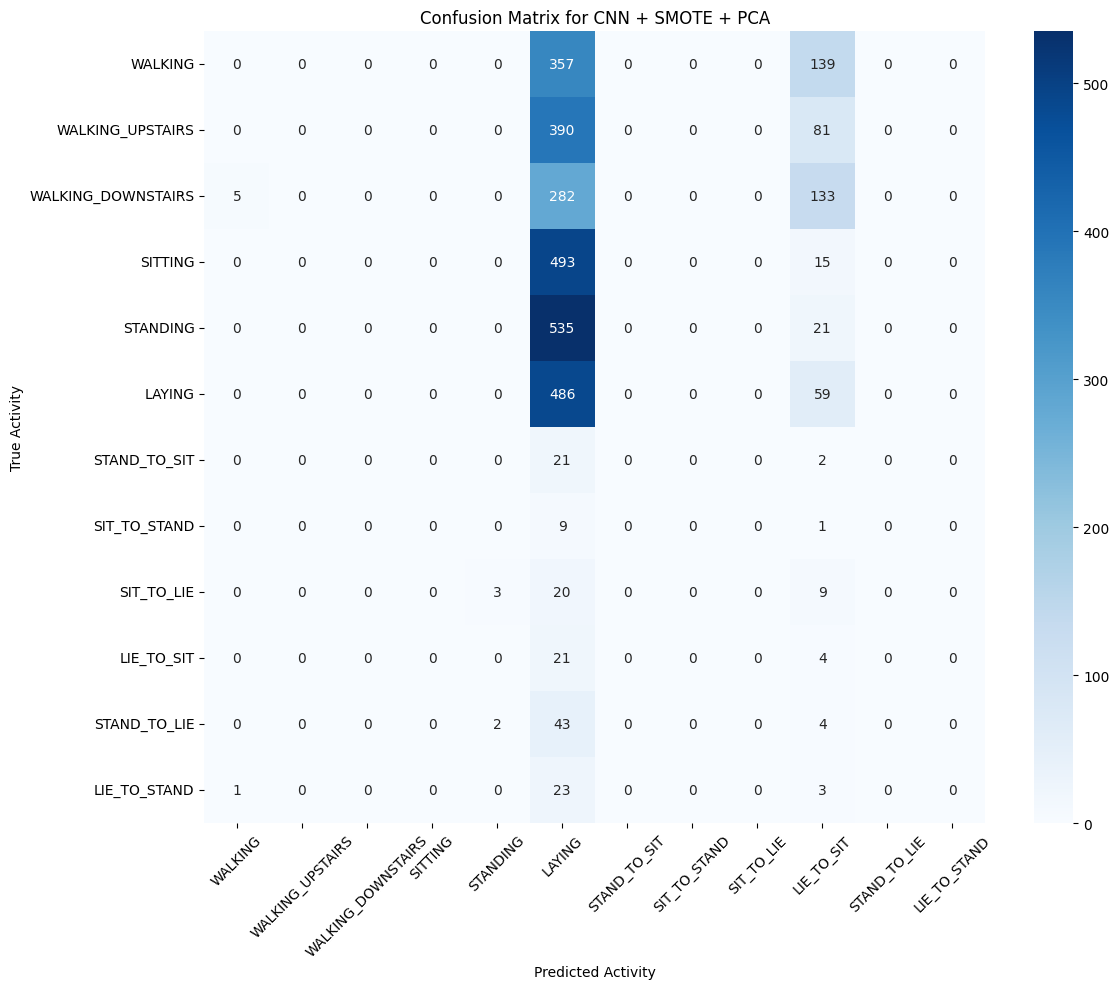

In [ ]:
# Predict on test set
y_pred_probs = model.predict(X_test_cnn)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# Classification Report
print("Classification Report:\n", classification_report(y_true, y_pred_classes))

# Confusion Matrix
conf_mat = confusion_matrix(y_true, y_pred_classes)

# Activity labels (from activity_labels.txt)
activity_labels = [
    "WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "SITTING",
    "STANDING", "LAYING", "STAND_TO_SIT", "SIT_TO_STAND", 
    "SIT_TO_LIE", "LIE_TO_SIT", "STAND_TO_LIE", "LIE_TO_STAND"
]

# Plot Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', 
            xticklabels=activity_labels, yticklabels=activity_labels)
plt.xlabel("Predicted Activity")
plt.ylabel("True Activity")
plt.title("Confusion Matrix for CNN + SMOTE + PCA")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()